# 3주차 심화 - 리랭킹 챗봇에 HyDE, Self-RAG 붙이고 RAGAS로 평가하기

TAVE 18기 DRAG 스터디 3주차

3-1에서 공부한 네 가지를 3-3 리랭킹 챗봇 위에 하나씩 얹어봤다.

| 파이프라인 | 흐름 |
|---|---|
| 기본 | 질문 → 벡터 검색 상위 3개 → 답변 (2주차) |
| 리랭킹 | 질문 → 벡터 검색 10개 → Cross-Encoder로 다시 채점 → 상위 3개 → 답변 (3-3) |
| HyDE + 리랭킹 | 질문 → LLM이 가상 답변 문서 작성 → 그 문서로 벡터 검색 10개 → 원래 질문으로 리랭킹 → 상위 3개 → 답변 |
| Self-RAG | 리랭킹 검색 → 문서마다 관련성 채점 → 관련 문서가 없으면 질문을 고쳐서 재검색 → 답변 → 답변이 문서에 근거하는지 점검 |

마지막에 네 파이프라인을 RAGAS 지표(Context Precision, Faithfulness, Answer Relevancy)로 같은 질문에 대해 비교한다.

실행 전 확인
- `런타임 → 런타임 유형 변경 → T4 GPU`
- 🔑 보안 비밀에 `GOOGLE_API_KEY` 등록 + 노트북 액세스 켜기

## 0. 패키지 설치
`ragas`가 최신 `langchain-community`(0.4.2)와 충돌해서 `0.4.1`로 고정했다. "세션 다시 시작" 안내가 뜨면 재시작하고 1번 셀부터 실행한다.

In [ ]:
!pip install -q langchain langchain-classic "langchain-community==0.4.1" langchain-google-genai langchain-huggingface sentence-transformers faiss-cpu beautifulsoup4 ragas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 87.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.6/81.6 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.4/269.4 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.4/127.4 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.1/572.1

## 1. API 키 / 실행 환경

In [ ]:
import os
import torch
from google.colab import userdata

os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")
os.environ["USER_AGENT"] = "Mozilla/5.0 (TAVE-DRAG-study)"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("사용 장치:", DEVICE)

사용 장치: cuda


## 2. 문서 로드 → 분할 → 임베딩 → 벡터스토어 (2주차와 동일)

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings

SOURCE_URL = "https://ko.wikipedia.org/wiki/인공지능"

docs = WebBaseLoader(web_paths=(SOURCE_URL,)).load()
splits = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100).split_documents(docs)
print(f"분할된 청크 수: {len(splits)}")

embeddings = HuggingFaceEmbeddings(
    model_name="jhgan/ko-sroberta-multitask",
    model_kwargs={"device": DEVICE},
    encode_kwargs={"normalize_embeddings": True},
)
vectorstore = FAISS.from_documents(documents=splits, embedding=embeddings)

분할된 청크 수: 86


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/4.86k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/585 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/495k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## 3. 검색기 (기본 / 리랭킹) - 3-3과 동일

In [ ]:
from langchain_classic.retrievers import ContextualCompressionRetriever
from langchain_classic.retrievers.document_compressors import CrossEncoderReranker
from langchain_community.cross_encoders import HuggingFaceCrossEncoder

TOP_K_CANDIDATES = 10
TOP_N = 3

base_retriever = vectorstore.as_retriever(search_kwargs={"k": TOP_N})

reranker_model = HuggingFaceCrossEncoder(
    model_name="BAAI/bge-reranker-v2-m3",
    model_kwargs={"device": DEVICE},
)
reranker = CrossEncoderReranker(model=reranker_model, top_n=TOP_N)
rerank_retriever = ContextualCompressionRetriever(
    base_compressor=reranker,
    base_retriever=vectorstore.as_retriever(search_kwargs={"k": TOP_K_CANDIDATES}),
)

config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.27GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.17k [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

## 4. LLM / 답변 프롬프트 (2주차와 동일)

In [ ]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_core.rate_limiters import InMemoryRateLimiter
from langchain_google_genai import ChatGoogleGenerativeAI

LLM_MODEL = "gemini-3.1-flash-lite"  # ai.dev/rate-limit에서 확인한 이름으로 바꾸기

rate_limiter = InMemoryRateLimiter(
    requests_per_second=0.15,  # 분당 약 9회
    check_every_n_seconds=0.5,
    max_bucket_size=1,
)
llm = ChatGoogleGenerativeAI(model=LLM_MODEL, temperature=0,
                             rate_limiter=rate_limiter, max_retries=6)

answer_prompt = PromptTemplate.from_template(
    """당신은 질문-답변(Question-Answering)을 수행하는 친절한 AI 어시스턴트입니다. 당신의 임무는 주어진 문맥(context) 에서 주어진 질문(question) 에 답하는 것입니다.
검색된 다음 문맥(context) 을 사용하여 질문(question) 에 답하세요. 만약, 주어진 문맥(context) 에서 답을 찾을 수 없다면, 답을 모른다면 `주어진 정보에서 질문에 대한 정보를 찾을 수 없습니다` 라고 답하세요.
한글로 답변해 주세요. 단, 기술적인 용어나 이름은 번역하지 않고 그대로 사용해 주세요.

#Question:
{question}

#Context:
{context}

#Answer:"""
)
answer_chain = answer_prompt | llm | StrOutputParser()


def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)


def preview(doc, length=80):
    return doc.page_content.replace("\n", " ")[:length] + "..."


print("사용 모델:", llm.model)
print("테스트:", llm.invoke("한 단어로 인사해줘").content)

사용 모델: gemini-3.1-flash-lite
테스트: [{'type': 'text', 'text': '안녕하세요!', 'extras': {'signature': 'EnMKcQFpFH0T+w/51kCEMWWdiSsL22AiuLd60KCWtDbxy30lbQzzXVDK2t3GOigIjB3g4p1P/I0X+DO+PQ/L2OIje64NlebLxDLP31JoFMaRZgCmopW5aRhUEe5xVX5f/SosJrNyuy2ESrYpZJdr71IEAlMW'}}]


## 5. HyDE (Hypothetical Document Embeddings)

질문은 짧은 의문문이고 문서는 설명문이라 둘을 바로 비교하면 형태가 달라서 검색이 빗나갈 수 있다.
그래서 LLM에게 **질문에 대한 가상의 답변 문단**을 먼저 쓰게 하고, 그 문단으로 벡터 검색을 한다.
가상 답변의 내용이 틀려도 괜찮다. 검색용 미끼로만 쓰고 LLM에 넘기지는 않는다.

후보 10개를 뽑은 뒤에는 **원래 질문**으로 리랭킹한다. 가상 문서는 넓게 찾는 데만 쓰고, 최종 선택은 실제 질문 기준으로 하기 위해서다.

In [ ]:
hyde_prompt = PromptTemplate.from_template(
    """다음 질문에 대한 답이 들어 있을 법한 백과사전 문단을 한국어로 3~4문장 작성하세요.
정확하지 않아도 괜찮으니 설명문 형식으로만 쓰세요.

질문: {question}
문단:"""
)
hyde_generator = hyde_prompt | llm | StrOutputParser()


def hyde_retrieve(question, verbose=False):
    hypothetical_doc = hyde_generator.invoke({"question": question})
    candidates = vectorstore.similarity_search(hypothetical_doc, k=TOP_K_CANDIDATES)
    reranked = reranker.compress_documents(candidates, question)  # 원래 질문으로 리랭킹
    if verbose:
        print("[가상 문서]\n" + hypothetical_doc + "\n")
        print("[HyDE + 리랭킹 상위 3개]")
        for i, d in enumerate(reranked, 1):
            print(f"  {i}위: {preview(d)}")
    return list(reranked)


_ = hyde_retrieve("인공지능의 겨울은 왜 찾아왔어?", verbose=True)

[가상 문서]
인공지능의 겨울은 초기 연구 단계에서 지나치게 낙관적인 기대와 달리, 복잡한 현실 세계의 문제를 해결하는 데 기술적 한계가 드러나면서 찾아왔습니다. 당시의 컴퓨터 성능으로는 방대한 데이터를 처리하기에 역부족이었고, 인공지능이 논리적 추론을 넘어 상식적인 판단을 내리는 데 실패하며 연구 자금 지원이 급격히 끊겼습니다. 이러한 실망감은 학계와 산업계 전반에 걸쳐 인공지능에 대한 회의론을 확산시켰고, 결과적으로 수십 년간 연구가 정체되는 침체기를 맞이하게 되었습니다.

[HyDE + 리랭킹 상위 3개]
  1위: 용어 용어집 vte 인공지능(영어: artificial intelligence, AI)은 컴퓨터가 학습, 추론, 지각, 언어 처리, 문제 해결,...
  2위: ‘인공지능’이라는 명칭은 존 매카시, 마빈 민스키, 너새니얼 로체스터와 클로드 섀넌이 작성한 1955년 연구 계획서에서 사용되었다. 이 계획서를...
  3위: 철학 AI 정렬 인공 의식 쓰라린 교훈 중국어 방 친절한 AI 윤리 실존적 위험 튜링 검사 불쾌한 골짜기 인간-AI 상호작용  역사 연표 진행상...


## 6. Self-RAG (간단 버전)

원래 Self-RAG 논문은 모델이 reflection token을 직접 생성하도록 학습시킨다. 여기서는 학습 없이 LLM에게 단계마다 판단을 시켜서 흐름만 구현했다.

1. **검색**: 리랭킹 검색기로 문서 3개를 가져온다.
2. **관련성 채점**: 문서마다 질문과 관련 있는지 yes/no로 채점하고 관련 있는 것만 남긴다.
3. **재검색**: 남은 문서가 하나도 없으면 질문을 검색하기 좋게 고쳐서 다시 검색한다. (최대 2번)
4. **답변 생성**: 관련 문서만으로 답변한다.
5. **근거 점검**: 답변이 문서에 근거하는지 yes/no로 확인하고, no면 한 번 다시 생성한다.

In [ ]:
import re

grade_prompt = PromptTemplate.from_template(
    """아래 문서들 중에서 질문에 답하는 데 도움이 되는 정보를 담은 문서 번호만 쉼표로 출력하세요.
도움이 되는 문서가 하나도 없으면 없음 이라고만 출력하세요.

질문: {question}

{documents}

도움이 되는 문서 번호:"""
)
rewrite_prompt = PromptTemplate.from_template(
    """다음 질문을 백과사전에서 검색하기 좋은 짧은 검색 문장으로 바꾸세요. 검색 문장만 출력하세요.

질문: {question}
검색 문장:"""
)
grounded_prompt = PromptTemplate.from_template(
    """답변의 내용이 모두 문서에 근거하고 있으면 yes, 문서에 없는 내용이 섞여 있으면 no로만 답하세요.

문서: {documents}
답변: {answer}
답(yes/no):"""
)

grader = grade_prompt | llm | StrOutputParser()
rewriter = rewrite_prompt | llm | StrOutputParser()
grounded_checker = grounded_prompt | llm | StrOutputParser()


def is_yes(text):
    return text.strip().lower().startswith("yes")


def grade_docs(question, docs):
    # 문서 여러 개를 한 번의 호출로 채점
    numbered = "\n\n".join(f"[문서 {i}]\n{d.page_content}" for i, d in enumerate(docs, 1))
    result = grader.invoke({"question": question, "documents": numbered})
    picked = {int(n) for n in re.findall(r"\d+", result)}
    return [d for i, d in enumerate(docs, 1) if i in picked]


def self_rag(question, max_retries=2, verbose=False):
    log = []
    query = question
    relevant = []

    for attempt in range(max_retries + 1):
        retrieved = rerank_retriever.invoke(query)
        relevant = grade_docs(question, retrieved)
        log.append(f"검색 {attempt + 1}회차 ('{query}'): 문서 {len(retrieved)}개 중 관련 {len(relevant)}개")
        if relevant:
            break
        query = rewriter.invoke({"question": question}).strip()

    if not relevant:
        log.append("관련 문서를 찾지 못해서 답변 생성 생략")
        return {"answer": "주어진 정보에서 질문에 대한 정보를 찾을 수 없습니다", "contexts": [], "log": log}

    context = format_docs(relevant)
    answer = answer_chain.invoke({"context": context, "question": question})
    grounded = is_yes(grounded_checker.invoke({"documents": context, "answer": answer}))
    log.append(f"근거 점검: {'통과' if grounded else '실패 → 다시 생성'}")

    if not grounded:
        answer = answer_chain.invoke({"context": context, "question": question})

    if verbose:
        print("\n".join(log))
        print("\n[답변]\n" + answer)
    return {"answer": answer, "contexts": [d.page_content for d in relevant], "log": log}


# _ = self_rag("튜링 테스트가 뭐야?", verbose=True)  # 동작 확인용 (호출 3번 쓰니 필요할 때만)

## 7. 네 파이프라인으로 같은 질문에 답하기

평가에 쓰려고 질문, 검색된 문서, 답변을 모두 저장한다.

In [ ]:
TEST_QUESTIONS = [
    "인공지능이라는 용어는 언제 누가 처음 사용했어?",
    "튜링 테스트가 뭐야?",
    "인공지능의 겨울은 왜 찾아왔어?",
    "강인공지능과 약인공지능의 차이는 뭐야?",
]


def run_simple(retrieve_fn, question):
    docs = retrieve_fn(question)
    answer = answer_chain.invoke({"context": format_docs(docs), "question": question})
    return {"answer": answer, "contexts": [d.page_content for d in docs]}


PIPELINES = {
    "기본": lambda q: run_simple(base_retriever.invoke, q),
    "리랭킹": lambda q: run_simple(rerank_retriever.invoke, q),
    "HyDE+리랭킹": lambda q: run_simple(hyde_retrieve, q),
    "Self-RAG": lambda q: self_rag(q),
}

records = {name: [] for name in PIPELINES}
for q in TEST_QUESTIONS:
    print("=" * 100)
    print(f"질문: {q}")
    for name, fn in PIPELINES.items():
        out = fn(q)
        records[name].append({
            "user_input": q,
            "retrieved_contexts": out["contexts"] or ["(검색된 문서 없음)"],
            "response": out["answer"],
        })
        print(f"\n[{name}]\n{out['answer']}")

질문: 인공지능이라는 용어는 언제 누가 처음 사용했어?

[기본]
주어진 정보에서 질문에 대한 정보를 찾을 수 없습니다. 

제공된 문맥에는 '인공지능'이라는 용어가 1955년에 작성된 다트머스 여름 연구 계획서에서 사용되었다는 내용은 있으나, 누가 처음 사용했는지에 대한 정보는 포함되어 있지 않습니다.

[리랭킹]
‘인공지능’이라는 용어는 1955년에 작성된 연구 계획서에서 존 매카시(John McCarthy), 마빈 민스키(Marvin Minsky), 너새니얼 로체스터(Nathaniel Rochester), 클로드 섀넌(Claude Shannon)에 의해 처음 사용되었습니다.

[HyDE+리랭킹]
‘인공지능’이라는 용어는 1955년에 작성된 연구 계획서에서 존 매카시(John McCarthy), 마빈 민스키(Marvin Minsky), 너새니얼 로체스터(Nathaniel Rochester), 클로드 섀넌(Claude Shannon)에 의해 처음 사용되었습니다.

[Self-RAG]
‘인공지능’이라는 용어는 1955년에 작성된 연구 계획서에서 존 매카시(John McCarthy), 마빈 민스키(Marvin Minsky), 너새니얼 로체스터(Nathaniel Rochester), 클로드 섀넌(Claude Shannon)에 의해 처음 사용되었습니다.
질문: 튜링 테스트가 뭐야?

[기본]
주어진 정보에서 질문에 대한 정보를 찾을 수 없습니다.

[리랭킹]
주어진 문맥에 따르면, 튜링 테스트(튜링 검사)는 1950년 앨런 튜링이 논문 〈Computing Machinery and Intelligence〉에서 제안한 '모방 게임'을 의미합니다. 이는 "기계가 생각할 수 있는가"라는 질문을 다루며, 기계의 지능을 어떻게 논의할 것인지에 관한 연구 방향을 제시한 것입니다.

[HyDE+리랭킹]
1950년 앨런 튜링이 논문 〈Computing Machinery and Intelligence〉에서 제안한 모방 게임으로, "기계가 생각할 수 있는가"라는 질문을 다루며 기계의 

## 8. RAGAS 평가

정답 데이터(ground truth)가 없어서 정답 없이 잴 수 있는 지표 세 개를 골랐다.

- **Context Precision** (`LLMContextPrecisionWithoutReference`): 가져온 문서 중 쓸모 있는 게 위쪽에 있는가 → 리랭킹 효과가 가장 잘 드러나는 지표
- **Faithfulness**: 답변 내용이 가져온 문서에 근거하는가 (환각이 적은가)
- **Answer Relevancy** (`ResponseRelevancy`): 답변이 질문에 맞는 말인가

채점하는 LLM도 Gemini를 쓰고, 임베딩은 2번에서 만든 ko-sroberta를 그대로 쓴다.
무료 키는 분당 호출 수 제한이 있어서 `max_workers=2`로 천천히 돌린다. 몇 분 걸린다.
결과에 `NaN`이 많이 보이면 호출 제한에 걸린 것이라 1~2분 쉬었다가 이 셀만 다시 실행하면 된다.

In [ ]:
import warnings
import pandas as pd
from ragas import evaluate, EvaluationDataset
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas.metrics import Faithfulness, ResponseRelevancy, LLMContextPrecisionWithoutReference
from ragas.run_config import RunConfig

warnings.filterwarnings("ignore", category=DeprecationWarning)

ragas_llm = LangchainLLMWrapper(llm)  # 4번 셀의 모델 + 속도 제한 그대로 사용
ragas_emb = LangchainEmbeddingsWrapper(embeddings)
run_config = RunConfig(max_workers=2, timeout=300)

METRIC_NAMES = {
    "llm_context_precision_without_reference": "Context Precision",
    "faithfulness": "Faithfulness",
    "answer_relevancy": "Answer Relevancy",
}

summary, details = {}, {}
for name, rows in records.items():
    print(f"\n▶ {name} 평가 중...")
    result = evaluate(
        dataset=EvaluationDataset.from_list(rows),
        metrics=[
            LLMContextPrecisionWithoutReference(),
            Faithfulness(),
            ResponseRelevancy(strictness=1),  # 호출 수를 줄이려고 1로 설정
        ],
        llm=ragas_llm,
        embeddings=ragas_emb,
        run_config=run_config,
    )
    df = result.to_pandas().rename(columns=METRIC_NAMES)
    details[name] = df
    summary[name] = df[list(METRIC_NAMES.values())].mean()

summary_df = pd.DataFrame(summary).T.round(3)
summary_df

/tmp/ipykernel_2554/2372115972.py:6: DeprecationWarning: Importing Faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import Faithfulness
  from ragas.metrics import Faithfulness, ResponseRelevancy, LLMContextPrecisionWithoutReference
/tmp/ipykernel_2554/2372115972.py:6: DeprecationWarning: Importing ResponseRelevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import ResponseRelevancy
  from ragas.metrics import Faithfulness, ResponseRelevancy, LLMContextPrecisionWithoutReference
/tmp/ipykernel_2554/2372115972.py:6: DeprecationWarning: Importing LLMContextPrecisionWithoutReference from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import LLMContextPrecisionWithoutRefe


▶ 기본 평가 중...


Evaluating:   0%|          | 0/12 [00:00<?, ?it/s]


▶ 리랭킹 평가 중...


Evaluating:   0%|          | 0/12 [00:00<?, ?it/s]


▶ HyDE+리랭킹 평가 중...


Evaluating:   0%|          | 0/12 [00:00<?, ?it/s]


▶ Self-RAG 평가 중...


Evaluating:   0%|          | 0/12 [00:00<?, ?it/s]

,Context Precision,Faithfulness,Answer Relevancy
기본,0.854,0.167,0.000
리랭킹,0.792,0.964,0.653
HyDE+리랭킹,0.833,0.964,0.653
Self-RAG,0.750,1.000,0.486


### 질문별 점수 보기
`name`을 바꾸면 다른 파이프라인의 질문별 점수를 볼 수 있다.

In [ ]:
name = "리랭킹"
details[name][["user_input"] + list(METRIC_NAMES.values())].round(3)

,user_input,Context Precision,Faithfulness,Answer Relevancy
0,인공지능이라는 용어는 언제 누가 처음 사용했어?,1.000,1.000,0.979
1,튜링 테스트가 뭐야?,1.000,1.000,0.966
2,인공지능의 겨울은 왜 찾아왔어?,0.833,1.000,0.000
3,강인공지능과 약인공지능의 차이는 뭐야?,0.333,0.857,0.666


## 9. 그래프로 비교

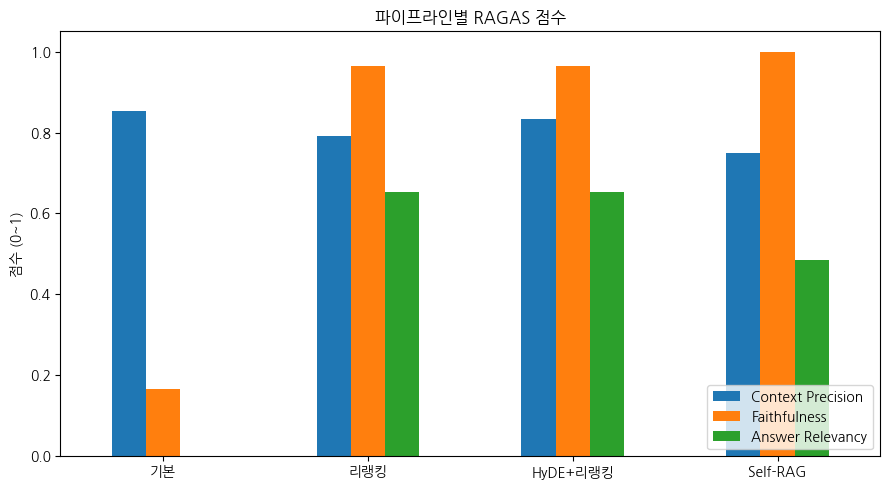

In [ ]:
import matplotlib.pyplot as plt

!apt-get -qq install -y fonts-nanum > /dev/null
import matplotlib.font_manager as fm
fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
plt.rcParams["font.family"] = "NanumGothic"

ax = summary_df.plot(kind="bar", figsize=(9, 5), ylim=(0, 1.05), rot=0)
ax.set_title("파이프라인별 RAGAS 점수")
ax.set_ylabel("점수 (0~1)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 10. 하이브리드 검색


In [ ]:
!pip install -q rank_bm25 kiwipiepy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 MB 11.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 111.0 MB/s eta 0:00:00


In [ ]:
from kiwipiepy import Kiwi
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever

kiwi = Kiwi()

def kiwi_tokenize(text):
    return [token.form for token in kiwi.tokenize(text)]

bm25_retriever = BM25Retriever.from_documents(splits, preprocess_func=kiwi_tokenize)
bm25_retriever.k = TOP_K_CANDIDATES
vector_candidates = vectorstore.as_retriever(search_kwargs={"k": TOP_K_CANDIDATES})

hybrid_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, vector_candidates],
    weights=[0.5, 0.5],
)
hybrid_rerank_retriever = ContextualCompressionRetriever(
    base_compressor=reranker,
    base_retriever=hybrid_retriever,
)


In [ ]:
def show_candidates(question):
    print("=" * 100)
    print(f"질문: {question}")
    for name, r in [("BM25 (키워드)", bm25_retriever),
                    ("벡터", vector_candidates),
                    ("하이브리드 + 리랭킹", hybrid_rerank_retriever)]:
        print(f"\n[{name}] 상위 3개")
        for i, d in enumerate(r.invoke(question)[:TOP_N], 1):
            print(f"  {i}위: {preview(d)}")


for q in TEST_QUESTIONS[:2]:
    show_candidates(q)



질문: 인공지능이라는 용어는 언제 누가 처음 사용했어?

[BM25 (키워드)] 상위 3개
  1위: 용어 용어집 vte 인공지능(영어: artificial intelligence, AI)은 컴퓨터가 학습, 추론, 지각, 언어 처리, 문제 해결,...
  2위: 법은 국가 인공지능 경쟁력 강화와 생태계 조성을 위해 연구개발, 인공지능 데이터·기반 시설, 전문 인력 양성, 중소기업과 창업 지원, 국제 협력...
  3위: ‘인공지능’이라는 명칭은 존 매카시, 마빈 민스키, 너새니얼 로체스터와 클로드 섀넌이 작성한 1955년 연구 계획서에서 사용되었다. 이 계획서를...

[벡터] 상위 3개
  1위: 용어 용어집 vte 인공지능(영어: artificial intelligence, AI)은 컴퓨터가 학습, 추론, 지각, 언어 처리, 문제 해결,...
  2위: [7] 예를 들어 정해진 시각에 조명을 켜는 타이머는 자동화 장치이고, 과거 이메일에서 배운 규칙으로 스팸을 가려내는 필터는 기계 학습을 이용한...
  3위: 관련 개념의 관계 인공지능은 알고리즘 및 자동화와 관련이 깊고, 기계 학습, 딥 러닝과 생성형 인공지능을 포괄하지만 서로 바꾸어 쓸 수 있는 말...

[하이브리드 + 리랭킹] 상위 3개
  1위: ‘인공지능’이라는 명칭은 존 매카시, 마빈 민스키, 너새니얼 로체스터와 클로드 섀넌이 작성한 1955년 연구 계획서에서 사용되었다. 이 계획서를...
  2위: 용어 용어집 vte 인공지능(영어: artificial intelligence, AI)은 컴퓨터가 학습, 추론, 지각, 언어 처리, 문제 해결,...
  3위: 두 방법을 결합하는 방식은 하나로 정해져 있지 않다. 신경망이 사진에서 사물과 그 위치를 찾은 뒤 기호적 규칙이 사물 사이의 관계를 추론할 수 ...
질문: 튜링 테스트가 뭐야?

[BM25 (키워드)] 상위 3개
  1위: 법은 국가 인공지능 경쟁력 강화와 생태계 조성을 위해 연구개발, 인공지능 데이터·기반 시설, 전문 인력 양성, 중소

In [ ]:
PIPELINES["하이브리드+리랭킹"] = lambda q: run_simple(hybrid_rerank_retriever.invoke, q)
records["하이브리드+리랭킹"] = []

for q in TEST_QUESTIONS:
    out = PIPELINES["하이브리드+리랭킹"](q)
    records["하이브리드+리랭킹"].append({
        "user_input": q,
        "retrieved_contexts": out["contexts"] or ["(검색된 문서 없음)"],
        "response": out["answer"],
    })
    print("=" * 100)
    print(f"질문: {q}\n\n{out['answer']}")

질문: 인공지능이라는 용어는 언제 누가 처음 사용했어?

‘인공지능’이라는 용어는 1955년에 작성된 연구 계획서에서 존 매카시(John McCarthy), 마빈 민스키(Marvin Minsky), 너새니얼 로체스터(Nathaniel Rochester), 클로드 섀넌(Claude Shannon)에 의해 처음 사용되었습니다.
질문: 튜링 테스트가 뭐야?

튜링 검사(Turing Test)는 1950년 앨런 튜링이 논문 〈Computing Machinery and Intelligence〉에서 제안한 모방 게임입니다. 이는 '생각'이라는 말을 정의하는 대신, 문자 대화만으로 사람과 기계를 구별할 수 있는지를 묻는 방식입니다.

심사자가 보이지 않는 사람과 기계에게 질문하고 답변을 비교했을 때, 기계를 사람과 안정적으로 구별하지 못한다면 그 기계는 사람과 구별하기 어려운 대화 행동을 보인 것으로 간주합니다. 다만, 튜링 검사는 대화 행동을 평가할 뿐 지능의 모든 형태나 이해·의식을 직접 측정하는 것은 아니며, 대화 시간이나 심사자 등 여러 변형이 존재하여 한 번의 결과만으로 통과 여부를 단정하기는 어렵습니다.
질문: 인공지능의 겨울은 왜 찾아왔어?

인공지능의 겨울이 찾아온 이유는 기술에 대한 높은 기대와 실제 성과 사이의 큰 차이 때문입니다. 구체적인 이유는 다음과 같습니다.

1. **첫 번째 인공지능의 겨울:** 초기 인공지능 프로그램들이 제한된 환경에서는 인상적인 결과를 보였으나, 실제 세계의 복잡성과 상식을 다루는 데 한계가 있었습니다. 당시 컴퓨터의 연산 능력과 메모리는 제한적이었고, 많은 문제에서 가능한 경우의 수가 너무 빠르게 늘어나는 문제에 직면했습니다. 이러한 기술적 한계로 인해 기대와 실제 시스템 능력 사이에 큰 차이가 발생하면서 1970년대 중반에 연구비와 관심이 줄어들었습니다.

2. **두 번째 인공지능의 겨울:** 1980년대 전문가 시스템 시장이 빠르게 성장했으나, 기대에 미치지 못하는 성과를 보이면서 관련 기업과 전용 하드웨어 시장이 위

In [ ]:
import asyncio
import uvicorn.server

# RAGAS가 바꿔놓은 asyncio.run 때문에 Gradio 서버가 안 뜨는 문제 해결
def _run(main, *, debug=None, loop_factory=None):
    loop = (loop_factory or asyncio.new_event_loop)()
    try:
        asyncio.set_event_loop(loop)
        return loop.run_until_complete(main)
    finally:
        loop.close()

uvicorn.server.asyncio_run = _run
gr.close_all()  # 실패한 서버 정리

11. Gradio 챗봇 화면

In [ ]:
import time
import gradio as gr

RETRIEVERS = {
    "기본": base_retriever,
    "리랭킹": rerank_retriever,
    "하이브리드+리랭킹": hybrid_rerank_retriever,
}
MODES = ["기본", "리랭킹", "HyDE+리랭킹", "하이브리드+리랭킹", "Self-RAG"]


def ask(question, mode):
    extra = ""
    if mode == "Self-RAG":
        out = self_rag(question)
        extra = "**Self-RAG 판단 과정**\n" + "\n".join(f"- {line}" for line in out["log"])
        return out["answer"], out["contexts"], extra

    if mode == "HyDE+리랭킹":
        hypothetical_doc = hyde_generator.invoke({"question": question})
        candidates = vectorstore.similarity_search(hypothetical_doc, k=TOP_K_CANDIDATES)
        docs = list(reranker.compress_documents(candidates, question))
        extra = "**HyDE가 만든 가상 문서**\n\n" + hypothetical_doc
    else:
        docs = RETRIEVERS[mode].invoke(question)

    answer = answer_chain.invoke({"context": format_docs(docs), "question": question})
    return answer, [d.page_content for d in docs], extra


def format_details(mode, seconds, contexts, extra):
    lines = [f"### {mode} · {seconds:.1f}초"]
    if extra:
        lines.append(extra)
    lines.append(f"**참고한 문서 {len(contexts)}개**")
    for i, c in enumerate(contexts, 1):
        text = c.replace("\n", " ")
        lines.append(f"{i}. {text[:300]}{'...' if len(text) > 300 else ''}")
    return "\n\n".join(lines)


def respond(message, history, mode):
    history = history or []
    if not message.strip():
        return "", history, gr.update()
    start = time.time()
    try:
        answer, contexts, extra = ask(message, mode)
    except Exception as e:
        answer, contexts, extra = f"오류가 났어요. 잠시 후 다시 시도해 주세요.\n\n`{e}`", [], ""
    history = history + [
        {"role": "user", "content": message},
        {"role": "assistant", "content": answer},
    ]
    return "", history, format_details(mode, time.time() - start, contexts, extra)


EMPTY_DETAILS = "질문하면 참고한 문서가 여기에 나와요."

with gr.Blocks(title="DRAG 미니 RAG 챗봇") as demo:
    gr.Markdown("# 📚 DRAG 미니 RAG 챗봇\n위키백과 '인공지능' 문서를 바탕으로 답해요.")
    with gr.Row():
        with gr.Column(scale=3):
            chatbot = gr.Chatbot(height=480, label="대화")
            msg = gr.Textbox(placeholder="질문을 입력하고 Enter", show_label=False)
            gr.Examples(TEST_QUESTIONS, inputs=msg)
        with gr.Column(scale=2):
            mode = gr.Radio(MODES, value="하이브리드+리랭킹", label="검색 방식")
            clear = gr.Button("대화 초기화")
            details = gr.Markdown(EMPTY_DETAILS)

    msg.submit(respond, [msg, chatbot, mode], [msg, chatbot, details])
    clear.click(lambda: ([], EMPTY_DETAILS), None, [chatbot, details])

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e8ad87dadf4d4d9080.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


12. 정답 데이터로 RAGAS 지표 추가

In [ ]:
df = result.to_pandas().rename(columns=METRIC_NAMES)
summary["하이브리드+리랭킹"] = df[list(METRIC_NAMES.values())].mean()
summary_df = pd.DataFrame(summary).T.round(3)
summary_df

,Context Precision,Faithfulness,Answer Relevancy
기본,0.854,0.167,0.000
리랭킹,0.792,0.964,0.653
HyDE+리랭킹,0.833,0.964,0.653
Self-RAG,0.750,1.000,0.486
하이브리드+리랭킹,1.000,1.000,0.920


### RAGAS 결과

| 방식 | Context Precision | Faithfulness | Answer Relevancy |
|---|---|---|---|
| 기본 | 0.854 | 0.167 | 0.000 |
| 리랭킹 | 0.792 | 0.964 | 0.653 |
| HyDE+리랭킹 | 0.833 | 0.964 | 0.653 |
| Self-RAG | 0.750 | 1.000 | 0.486 |
| 하이브리드+리랭킹 | 1.000 | 1.000 | 0.920 |

- 하이브리드+리랭킹이 세 지표 모두 가장 높았다. BM25가 고유명사가 들어간 질문에서 정확한 문서를 후보로 올려주고, 리랭커가 그중 질문에 맞는 문서를 골라준 것으로 보인다.
- 기본 방식은 문서를 제대로 못 찾아서 "정보를 찾을 수 없다"고 답한 경우가 많았고, 그래서 Faithfulness와 Answer Relevancy가 크게 낮았다. 리랭킹만 붙여도 두 점수가 크게 올랐다.
- HyDE는 Context Precision이 조금 올랐지만 답변 점수는 리랭킹과 같았다. LLM 호출이 한 번 더 드는 것에 비해 효과는 작았다.
- Self-RAG는 관련 문서만 남겨서 답변이 문서에서 벗어나지 않았지만(Faithfulness 1.0), 너무 엄격하게 걸러서 답변이 부족해진 질문이 있었다.
- 최종적으로 우리 챗봇에는 하이브리드 검색 + 리랭킹 조합이 가장 적합하다고 판단했다.

### 한계
- 질문이 4개뿐이라 표본이 별루 없어서 점수 차이가 우연일 수 있다.
- 채점도 Gemini Flash-Lite가 해서 채점 자체에 오차가 있을 수 있다.
- 한도 문제로 중간에 모델을 바꿔서, 첫 질문의 기본/리랭킹 답변만 이전 모델로 만들어졌다.